# Catalogues as Data: Isolate Analysis
**James Baker, University of Southampton**

---

## Purpose

This notebook analyses the 76.2% of NLS Moving Image Archive records (17,906 of 23,491) that are **isolates** — records with no pairwise similarity partner above the 0.65 threshold used in `community_analysis_v9.ipynb`. Isolates are not failures of the method; they are structurally distinctive records that share too little with any other record to form a community link. Analysis shows isolates are systematically *richer* than in-graph records: 90% shotlist, 59% timecodes, mean 211 words vs 18% shotlist, 4% timecodes, mean 46 words for in-graph records.

The analytical question is: what does the isolate population tell us about the catalogue's knowledge labour that the community detection approach cannot?

---

## Notebook structure

- **Section A** — Isolate identification and feature profiling
- **Section B** — Genre and content-type distribution
- **Section C** — Temporal distribution (film date)
- **Section D** — Length and structural complexity
- **Section E** — TF-IDF clustering within the isolate population (three cells: E-setup · E-elbow · E-cluster)
- **Section F** — Qualitative inspection: the most and least distinctive isolates
- **Section G** — Close reading dossier: top terms + structural profile + sampled record previews per cluster, saved as Markdown

---

## Global configuration

Set input files here. All sections read from these variables.


In [4]:
import os, datetime, sys

# ── Utility imports ───────────────────────────────────────────────────────────
# utils.py lives alongside this notebook; add the notebook directory to sys.path
# so it can be imported regardless of the working directory Jupyter uses.
_nb_dir = os.path.dirname(os.path.abspath('__file__'))
if _nb_dir not in sys.path:
    sys.path.insert(0, _nb_dir)

from utils import latest_communities_tsv

# ── Input files ───────────────────────────────────────────────────────────────
# FEATURES_FILE and PAIRWISE_FILE are produced by pairwise_comparison_v5.ipynb
# and do not change between community analysis runs.
FEATURES_FILE = 'derived-data/features_individual_records_20260313-120649.tsv'
PAIRWISE_FILE = 'derived-data/pairwise_individual_records_20260313-120649.tsv'

# RECORDS_DIR: same directory used in pairwise_comparison_v5.ipynb.
# Required for Section E (TF-IDF) which reads description text from XML files.
RECORDS_DIR = '../data/nls-moving-image-archive-2025/individual_records'

# Auto-detect the most recent communities TSV by the timestamp in its filename.
# Warns if more than one file is found and advises archiving old files to
# derived-data/attic/ to suppress the warning.
COMMUNITIES_FILE = latest_communities_tsv('derived-data/communities_*.tsv')

# ── Output directories ────────────────────────────────────────────────────────
TIMESTAMP = datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
VIS_DIR   = 'visualisations'
DATA_DIR  = 'derived-data'

# ── Threshold (must match community_analysis_v9) ──────────────────────────────
GRAPH_THRESHOLD = 0.65

print(f'Timestamp:        {TIMESTAMP}')
print(f'Features file:    {FEATURES_FILE}')
print(f'Pairwise file:    {PAIRWISE_FILE}')
print(f'Records dir:      {RECORDS_DIR}')
print(f'Communities file: {COMMUNITIES_FILE}')


Timestamp:        20260423-173447
Features file:    derived-data/features_individual_records_20260313-120649.tsv
Pairwise file:    derived-data/pairwise_individual_records_20260313-120649.tsv
Records dir:      ../data/nls-moving-image-archive-2025/individual_records
Communities file: derived-data/communities_individual_records_20260417-152942.tsv


---
## Section A — Isolate identification and feature profiling

**Purpose**: Identify isolates by finding records in the features file that have no community assignment in the communities file. Profile them on all structural features and compare to in-graph records.

**Expected output**: A summary table comparing isolate vs in-graph records across: shotlist %, timecodes %, credit line %, mean word count, median word count, n_subjects, n_creators. Plus a bar chart visualising the comparison.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
feat   = pd.read_csv(FEATURES_FILE, sep='\t')
comms  = pd.read_csv(COMMUNITIES_FILE, sep='\t')

# Identify in-graph records (those with a community assignment)
in_graph_refs = set(comms['film_ref'])
feat['in_graph'] = feat['film_ref'].isin(in_graph_refs)

isolates = feat[~feat['in_graph']].copy()
in_graph = feat[ feat['in_graph']].copy()

print(f'Total records:    {len(feat):,}')
print(f'In-graph records: {len(in_graph):,} ({len(in_graph)/len(feat)*100:.1f}%)')
print(f'Isolates:         {len(isolates):,} ({len(isolates)/len(feat)*100:.1f}%)')
print()

# Feature comparison table
comparison = pd.DataFrame({
    'In-graph': [
        f"{in_graph['has_shotlist'].mean()*100:.1f}%",
        f"{in_graph['has_timecodes'].mean()*100:.1f}%",
        f"{in_graph['has_credit_line'].mean()*100:.1f}%",
        f"{in_graph['desc_word_count'].mean():.0f}",
        f"{in_graph['desc_word_count'].median():.0f}",
        f"{in_graph['n_subjects'].mean():.1f}",
    ],
    'Isolates': [
        f"{isolates['has_shotlist'].mean()*100:.1f}%",
        f"{isolates['has_timecodes'].mean()*100:.1f}%",
        f"{isolates['has_credit_line'].mean()*100:.1f}%",
        f"{isolates['desc_word_count'].mean():.0f}",
        f"{isolates['desc_word_count'].median():.0f}",
        f"{isolates['n_subjects'].mean():.1f}",
    ]
}, index=['Shotlist %', 'Timecodes %', 'Credit line %', 'Mean word count', 'Median word count', 'Mean subjects'])

print(comparison.to_string())


Total records:    23,491
In-graph records: 5,585 (23.8%)
Isolates:         17,906 (76.2%)

                  In-graph Isolates
Shotlist %           18.2%    90.2%
Timecodes %           3.6%    58.6%
Credit line %        68.5%    56.9%
Mean word count         46      211
Median word count       31      134
Mean subjects          0.3      1.2


---
## Section B — Genre and content-type distribution

**Purpose**: Compare genre_tag distributions between isolates and in-graph records. Are isolates concentrated in particular genre categories? The expectation (from preliminary analysis) is that isolates skew strongly towards traditional non-fiction and non-TV content.

**Key question**: Is the TV/non-TV split different in the isolate vs in-graph populations?


In [6]:
import pandas as pd

# TV vs non-TV in isolates vs in-graph
feat['is_tv'] = feat['genre_tag'].str.contains('television', na=False)
isolates = feat[~feat['in_graph']].copy()
in_graph = feat[feat['in_graph']].copy()

print('=== TV vs non-TV: isolates vs in-graph ===')
for label, subset in [('In-graph', in_graph), ('Isolates', isolates)]:
    tv_pct = subset['is_tv'].mean() * 100
    print(f'{label}: TV = {tv_pct:.1f}%, non-TV = {100 - tv_pct:.1f}%')

print()

# Top genre tags in isolates
print('=== Top 20 genre tags in isolates ===')
print(isolates['genre_tag'].value_counts().head(20).to_string())

print()
print('=== Top 20 genre tags in in-graph records ===')
print(in_graph['genre_tag'].value_counts().head(20).to_string())


=== TV vs non-TV: isolates vs in-graph ===
In-graph: TV = 38.4%, non-TV = 61.6%
Isolates: TV = 10.7%, non-TV = 89.3%

=== Top 20 genre tags in isolates ===
genre_tag
non-fiction                                    8544
non-fiction; amateur                           1933
fiction                                         811
non-fiction; television news                    616
non-fiction; television documentary             517
non-fiction; documentary                        413
non-fiction; local topical                      386
non-fiction; educational                        307
non-fiction; sponsored                          298
non-fiction; newsreel                           226
non-fiction; promotional                        172
non-fiction; amateur home movies and videos     160
non-fiction; television arts                    140
fiction; amateur                                121
non-fiction; television sport                   119
non-fiction; activist                           116
fi

---
## Section C — Temporal distribution (film date)

**Purpose**: Compare the distribution of film dates (dcterms:date) between isolates and in-graph records. Are isolates concentrated in particular decades?

**Reminder**: dcterms:date records when the film was created or shown, not when the record was catalogued.

**Expected pattern**: Isolates should skew towards earlier film dates (pre-television era), consistent with the professional film archive tradition that produces long, individually-described records.


 decade  total  isolate_pct  in_graph_pct
   1910   89.0   100.000000      0.000000
   1920  227.0    96.035242      3.964758
   1930 1197.0    97.326650      2.673350
   1940  987.0    93.211753      6.788247
   1950 2111.0    93.889152      6.110848
   1960 2558.0    95.856138      4.143862
   1970 3264.0    96.813725      3.186275
   1980 2277.0    94.158981      5.841019
   1990 1457.0    41.866850     58.133150
   2000 1895.0    46.543536     53.456464
   2010 1485.0    58.181818     41.818182
   2020  190.0    95.789474      4.210526


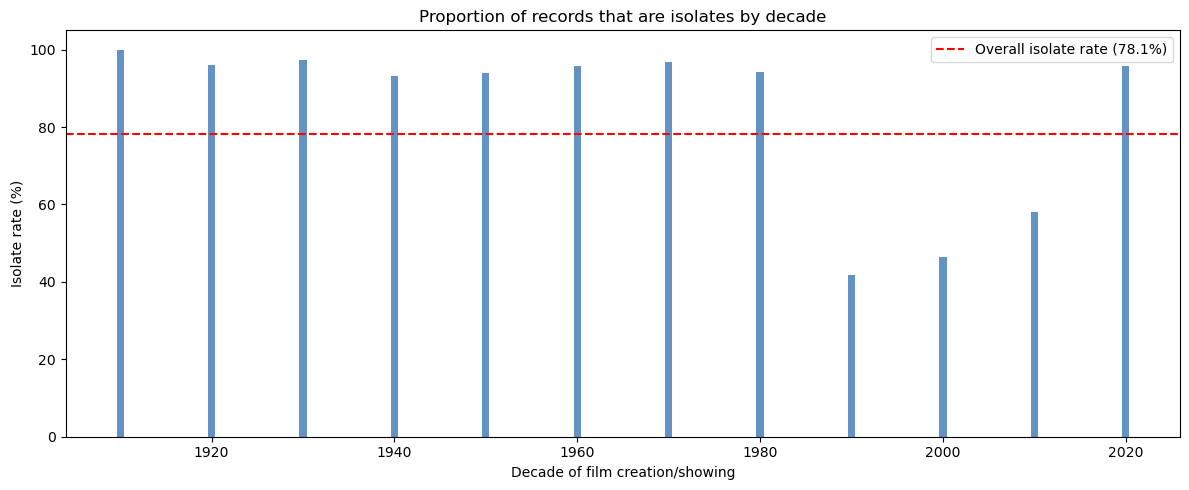

Figure saved.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

feat['decade'] = (feat['year'] // 10 * 10).astype('Int64')
isolates = feat[~feat['in_graph']].copy()
in_graph = feat[feat['in_graph']].copy()

# Proportion of each decade that are isolates
decade_split = feat.groupby('decade').apply(
    lambda x: pd.Series({
        'total': len(x),
        'isolate_pct': (~x['in_graph']).mean() * 100,
        'in_graph_pct': x['in_graph'].mean() * 100
    })
).reset_index()

# Filter to decades with ≥50 records
decade_split = decade_split[decade_split['total'] >= 50]
print(decade_split.to_string(index=False))

# Plot: isolate rate by decade
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(decade_split['decade'].astype(int), decade_split['isolate_pct'], color='#2166ac', alpha=0.7)
ax.set_xlabel('Decade of film creation/showing')
ax.set_ylabel('Isolate rate (%)')
ax.set_title('Proportion of records that are isolates by decade')
ax.axhline(y=78.1, color='red', linestyle='--', label='Overall isolate rate (78.1%)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{VIS_DIR}/isolate-rate-by-decade_{TIMESTAMP}.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')


---
## Section D — Length and structural complexity

**Purpose**: Profile the word count and structural complexity distribution of isolates. Are isolates uniformly rich, or is there a bimodal distribution (very long detailed records + short boilerplate records that are too individually phrased to pair)?

**Key question**: Is isolation a proxy for description quality (longer = richer = more isolated), or are there short isolates that are isolated for different reasons?


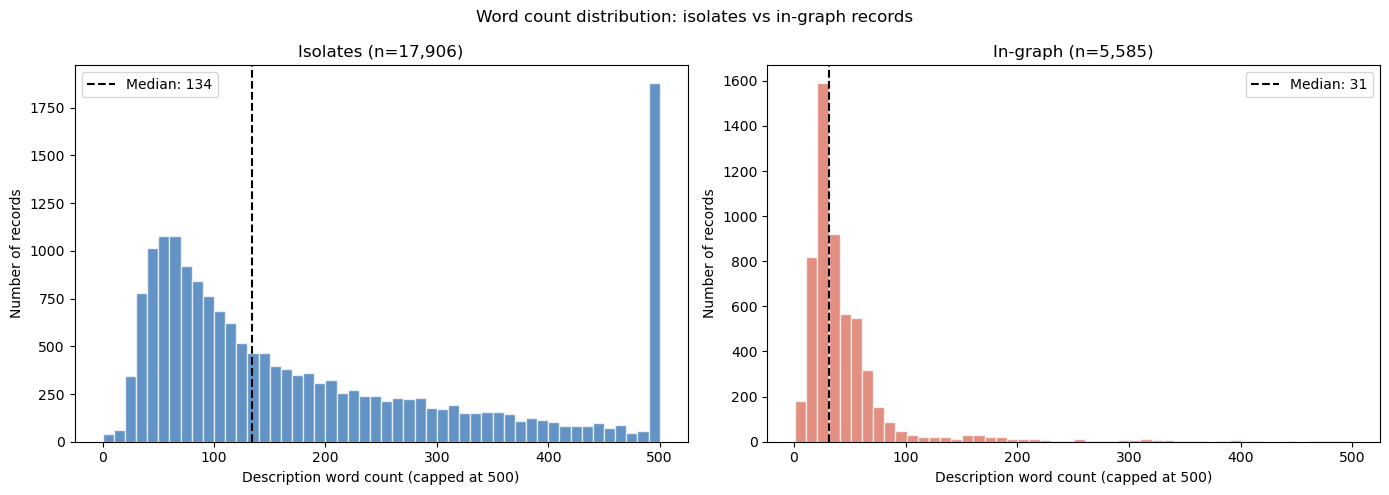

Isolates with <20 words: 102 (0.6%)
Their genre distribution:
genre_tag
non-fiction                                                            52
fiction                                                                 6
producer, mactv.                                                        4
non-fiction; television documentary                                     3
non-fiction; television arts                                            2
non-fiction; educational                                                2
non-fiction; amateur                                                    1
non-fiction; documentary                                                1
children's animated series. [not subtitled] episode 1. the lost zoo     1
producer, [p.c. eolas productions].                                     1


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

isolates = feat[~feat['in_graph']].copy()
in_graph = feat[feat['in_graph']].copy()

# Word count distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Word count distribution: isolates vs in-graph records', fontsize=12)

for ax, (label, subset, color) in zip(axes, [
    ('Isolates', isolates, '#2166ac'),
    ('In-graph', in_graph, '#d6604d')
]):
    # Cap at 500 words for readability
    wc = subset['desc_word_count'].clip(upper=500)
    ax.hist(wc, bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.set_xlabel('Description word count (capped at 500)')
    ax.set_ylabel('Number of records')
    ax.set_title(f'{label} (n={len(subset):,})')
    ax.axvline(x=subset['desc_word_count'].median(), color='black', linestyle='--',
               label=f'Median: {subset["desc_word_count"].median():.0f}')
    ax.legend()

plt.tight_layout()
plt.savefig(f'{VIS_DIR}/isolate-word-count-distribution_{TIMESTAMP}.png', dpi=150, bbox_inches='tight')
plt.show()

# Short isolates: how many have fewer than 20 words?
short_isolates = isolates[isolates['desc_word_count'] < 20]
print(f'Isolates with <20 words: {len(short_isolates):,} ({len(short_isolates)/len(isolates)*100:.1f}%)')
print(f'Their genre distribution:')
print(short_isolates['genre_tag'].value_counts().head(10).to_string())


---
## Section E — TF-IDF clustering within the isolate population

**Purpose**: Apply TF-IDF vectorisation and KMeans clustering to the isolate
population alone to detect thematic or vocabulary-based groupings that
SequenceMatcher cannot find (SM detects shared *phrasing*; TF-IDF detects
shared *vocabulary*). Description text is read directly from the original XML
records in `RECORDS_DIR` — the same source used by Batch F of
`community_analysis_v9.ipynb`.

Three cells:
1. **E-setup** — extract description text from XML, filter to isolates
2. **E-elbow** — compute KMeans inertia for a range of k to guide cluster count selection
3. **E-cluster** — fit KMeans at chosen k, profile clusters by genre and structural features


In [9]:
# ── Section E setup: extract description text and vectorise ───────────────────
# Uses tfidf_utils.load_descriptions() and tfidf_utils.fit_tfidf() rather than
# duplicating the XML-extraction and TF-IDF logic here.

import sys, os
import pandas as pd

_nb_dir = os.path.dirname(os.path.abspath('__file__'))
if _nb_dir not in sys.path:
    sys.path.insert(0, _nb_dir)

from tfidf_utils import load_descriptions, fit_tfidf

try:
    from sklearn.preprocessing import normalize
except ImportError:
    import subprocess
    print('Installing scikit-learn ...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                           'scikit-learn', '-q', '--break-system-packages'])
    from sklearn.preprocessing import normalize

# isolates must already be defined (run Section A first)
isolate_refs = set(isolates['film_ref'])

desc_df = load_descriptions(RECORDS_DIR, filter_refs=isolate_refs)
n_empty = (desc_df['description_text'].str.strip().str.len() == 0).sum()

print(f'Isolate records:             {len(isolate_refs):,}')
print(f'  matched in RECORDS_DIR:    {len(desc_df):,}')
print(f'  with non-empty description:{len(desc_df) - n_empty:,}')
print(f'  empty description:         {n_empty:,}')

# Drop empty descriptions before vectorising
desc_df = desc_df[desc_df['description_text'].str.strip().str.len() > 0].reset_index(drop=True)

vectorizer, X, _min_df = fit_tfidf(desc_df['description_text'])
print(f'\nTF-IDF matrix: {X.shape[0]:,} records \u00d7 {X.shape[1]:,} terms  (min_df={_min_df})')
print('\nSection E setup complete. Run E-elbow cell to choose k.')


Isolate records:             17,906
  matched in RECORDS_DIR:    17,905
  with non-empty description:17,887
  empty description:         18

TF-IDF matrix: 17,887 records × 10,000 terms  (min_df=3)

Section E setup complete. Run E-elbow cell to choose k.


Computing inertia for k = 5 … 50 ...
  k=  5  inertia=16,842  (0s)
  k= 10  inertia=16,648  (1s)
  k= 15  inertia=16,512  (3s)
  k= 20  inertia=16,418  (6s)
  k= 25  inertia=16,324  (8s)
  k= 30  inertia=16,259  (11s)
  k= 35  inertia=16,192  (15s)
  k= 40  inertia=16,135  (18s)
  k= 45  inertia=16,073  (23s)
  k= 50  inertia=16,027  (27s)


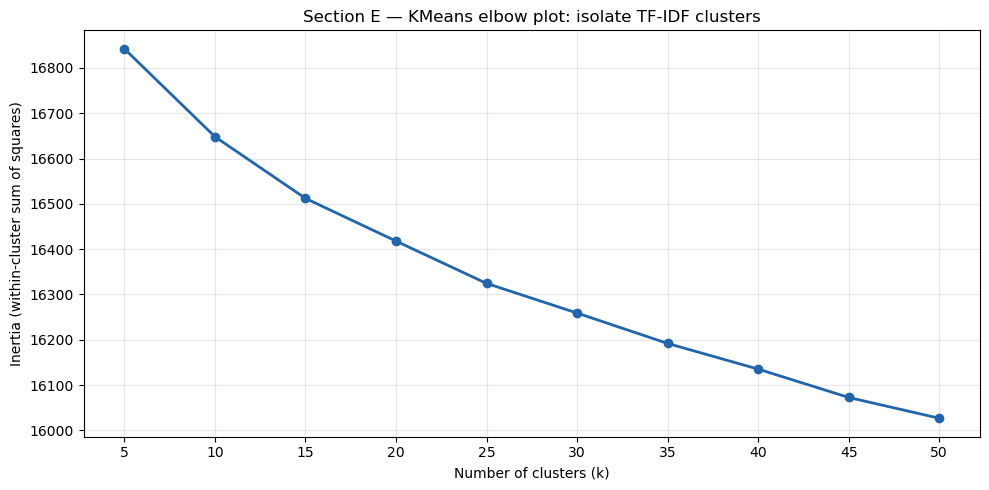

Elbow plot saved to: /Users/jwbaker/Library/CloudStorage/Dropbox/root/Southampton/Projects/ERC/code/visualisations/tfidf-elbow_20260423-173447.png
Elbow plot saved. Set TFIDF_K in the next cell based on the elbow.


In [10]:
# ── Section E elbow: choose number of clusters k ──────────────────────────────
# Uses tfidf_utils.kmeans_elbow(). Set TFIDF_K in the clustering cell below
# based on the elbow in the plot.

import sys, os
_nb_dir = os.path.dirname(os.path.abspath('__file__'))
if _nb_dir not in sys.path:
    sys.path.insert(0, _nb_dir)

from tfidf_utils import kmeans_elbow

inertias, K_RANGE = kmeans_elbow(
    X,
    k_range=list(range(5, 51, 5)),
    vis_dir=VIS_DIR,
    timestamp=TIMESTAMP,
    title='Section E \u2014 KMeans elbow plot: isolate TF-IDF clusters'
)

print('Elbow plot saved. Set TFIDF_K in the next cell based on the elbow.')


# ── Section E clustering: fit KMeans and profile clusters ─────────────────────
# Set TFIDF_K to the elbow value from the previous cell before running.

import pandas as pd
import matplotlib.pyplot as plt

TFIDF_K = 20  # ← set based on elbow plot above

km_final = KMeans(n_clusters=TFIDF_K, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X)
desc_df["tfidf_cluster"] = cluster_labels

# Merge cluster labels back onto isolate features.
# Cast tfidf_cluster to int after merge: left-join NaN coerces to float64;
# records without description text (n=18) are assigned cluster -1.
iso_clustered = isolates.merge(desc_df[["film_ref", "tfidf_cluster"]], on="film_ref", how="left")
iso_clustered["tfidf_cluster"] = iso_clustered["tfidf_cluster"].fillna(-1).astype(int)

# ── Cluster profiles ────────────────────────────────────────────────────────────
profile = iso_clustered.groupby("tfidf_cluster").agg(
    n_records        = ("film_ref",        "count"),
    shotlist_pct     = ("has_shotlist",     "mean"),
    timecodes_pct    = ("has_timecodes",    "mean"),
    credit_pct       = ("has_credit_line",  "mean"),
    mean_words       = ("desc_word_count",  "mean"),
    is_tv_pct        = ("is_tv",            "mean"),
    median_year      = ("year",             "median"),
).sort_values("n_records", ascending=False)

profile["shotlist_pct"] = (profile["shotlist_pct"] * 100).round(1)
profile["timecodes_pct"] = (profile["timecodes_pct"] * 100).round(1)
profile["credit_pct"]   = (profile["credit_pct"]   * 100).round(1)
profile["is_tv_pct"]    = (profile["is_tv_pct"]    * 100).round(1)
profile["mean_words"]   = profile["mean_words"].round(0).astype(int)

print(f"=== TF-IDF cluster profiles (k={TFIDF_K}) ===")
print(profile.to_string())

# ── Top terms per cluster ────────────────────────────────────────────────────
print("\n=== Top 10 terms per cluster ===")
terms = vectorizer.get_feature_names_out()
order = km_final.cluster_centers_.argsort()[:, ::-1]
for c in range(TFIDF_K):
    top_terms = ", ".join(terms[order[c, :10]])
    n = profile.loc[c, "n_records"] if c in profile.index else 0
    print(f"  Cluster {c:2d} (n={n:5,}): {top_terms}")

# ── Top genre tag per cluster ────────────────────────────────────────────────
print("\n=== Dominant genre tag per cluster ===")
for c in range(TFIDF_K):
    top_genre = iso_clustered[iso_clustered["tfidf_cluster"] == c]["genre_tag"].value_counts()
    if len(top_genre):
        print(f"  Cluster {c:2d}: {top_genre.index[0]}  ({top_genre.iloc[0]} records)")

# ── Save cluster assignments ─────────────────────────────────────────────────
out_path = f"{DATA_DIR}/isolate-tfidf-clusters_{TIMESTAMP}.tsv"
iso_clustered[["film_ref", "tfidf_cluster"]].to_csv(out_path, sep="\t", index=False)
print(f"\nCluster assignments saved to: {out_path}")

In [11]:
# ── Section E clustering: fit KMeans and profile clusters ─────────────────────
# Uses tfidf_utils.fit_kmeans(). Set TFIDF_K to the elbow value from the plot above.

import sys, os
import pandas as pd
_nb_dir = os.path.dirname(os.path.abspath('__file__'))
if _nb_dir not in sys.path:
    sys.path.insert(0, _nb_dir)

from tfidf_utils import fit_kmeans

TFIDF_K = 20  # \u2190 set based on elbow plot above

km_final, cluster_labels = fit_kmeans(X, TFIDF_K)
desc_df['tfidf_cluster'] = cluster_labels

# Merge cluster labels back onto isolate features.
# Cast tfidf_cluster to int after merge: left-join NaN coerces to float64;
# records without description text (n=18) are assigned cluster -1.
iso_clustered = isolates.merge(desc_df[['film_ref', 'tfidf_cluster']], on='film_ref', how='left')
iso_clustered['tfidf_cluster'] = iso_clustered['tfidf_cluster'].fillna(-1).astype(int)

# ── Cluster profiles ──────────────────────────────────────────────────────────
profile = iso_clustered.groupby('tfidf_cluster').agg(
    n_records        = ('film_ref',        'count'),
    shotlist_pct     = ('has_shotlist',     'mean'),
    timecodes_pct    = ('has_timecodes',    'mean'),
    credit_pct       = ('has_credit_line',  'mean'),
    mean_words       = ('desc_word_count',  'mean'),
    is_tv_pct        = ('is_tv',            'mean'),
    median_year      = ('year',             'median'),
).sort_values('n_records', ascending=False)

profile['shotlist_pct'] = (profile['shotlist_pct'] * 100).round(1)
profile['timecodes_pct'] = (profile['timecodes_pct'] * 100).round(1)
profile['credit_pct']   = (profile['credit_pct']   * 100).round(1)
profile['is_tv_pct']    = (profile['is_tv_pct']    * 100).round(1)
profile['mean_words']   = profile['mean_words'].round(0).astype(int)

print(f'=== TF-IDF cluster profiles (k={TFIDF_K}) ===')
print(profile.to_string())

# ── Top terms per cluster ──────────────────────────────────────────────────────
print('\n=== Top 10 terms per cluster ===')
terms = vectorizer.get_feature_names_out()
order = km_final.cluster_centers_.argsort()[:, ::-1]
for c in range(TFIDF_K):
    top_terms = ', '.join(terms[order[c, :10]])
    n = profile.loc[c, 'n_records'] if c in profile.index else 0
    print(f'  Cluster {c:2d} (n={n:5,}): {top_terms}')

# ── Top genre tag per cluster ──────────────────────────────────────────────────
print('\n=== Dominant genre tag per cluster ===')
for c in range(TFIDF_K):
    top_genre = iso_clustered[iso_clustered['tfidf_cluster'] == c]['genre_tag'].value_counts()
    if len(top_genre):
        print(f'  Cluster {c:2d}: {top_genre.index[0]}  ({top_genre.iloc[0]} records)')

# ── Save cluster assignments ───────────────────────────────────────────────────
out_path = f'{DATA_DIR}/isolate-tfidf-clusters_{TIMESTAMP}.tsv'
iso_clustered[['film_ref', 'tfidf_cluster']].to_csv(out_path, sep='\t', index=False)
print(f'\nCluster assignments saved to: {out_path}')

# ── Why k=20? ─────────────────────────────────────────────────────────────────
# k=20 is a manually chosen parameter. The elbow plot for this corpus
# (17,887 isolate records) flattens in the k=15-25 range, meaning that
# adding more clusters beyond ~15 produces diminishing reductions in
# within-cluster variance. k=20 gives roughly 900 records per cluster on
# average, which is large enough to be statistically meaningful but small
# enough to be interpretable in close reading. Adjust TFIDF_K above if you
# want to explore finer or coarser groupings.


=== TF-IDF cluster profiles (k=20) ===
               n_records  shotlist_pct  timecodes_pct  credit_pct  mean_words  is_tv_pct  median_year
tfidf_cluster                                                                                        
 11                 2900          75.8           37.1        52.7         123        9.4       1986.0
 14                 1706          99.9           84.8        71.6         179        0.9       1951.0
 10                 1436         100.0           93.4        65.4         429        8.1       1968.0
 1                  1428          98.3           88.1        47.4          74       31.7       1973.0
 8                  1266         100.0            0.1         0.9         565        0.5       1988.0
 17                 1198          51.5            0.0        96.3         170       33.5       2013.0
 13                  997          99.8           90.8        58.1         225        4.8       1959.0
 3                   966          99.7     

---
## Section F — Qualitative inspection: the most and least distinctive isolates

**Purpose**: Sample the isolate population at the extremes for qualitative close reading.

**'Most distinctive'**: Isolates with the longest descriptions, highest shotlist+timecode+credit line co-presence, and highest subject count — these are the peak of the traditional film archive cataloguing tradition.

**'Least distinctive'**: Isolates with the shortest descriptions and fewest structural features — these are the records isolated not by richness but by some other property. Worth inspecting: are these records with unusual vocabulary, title-only descriptions, or records from unusual genres?


In [12]:
import pandas as pd

isolates = feat[~feat['in_graph']].copy()

# Compute a 'structural richness' score: sum of has_shotlist + has_timecodes + has_credit_line (0-3)
for col in ['has_shotlist', 'has_timecodes', 'has_credit_line']:
    isolates[col] = isolates[col].astype(int)
isolates['richness_score'] = isolates['has_shotlist'] + isolates['has_timecodes'] + isolates['has_credit_line']

# Most 'traditional': high richness + long description
top_traditional = isolates[
    (isolates['richness_score'] == 3)
].nlargest(20, 'desc_word_count')[['film_ref', 'title', 'year', 'genre_tag', 'desc_word_count', 'n_subjects']]

print('=== Top 20 most structurally rich isolates (shotlist + timecodes + credit, longest descriptions) ===')
print(top_traditional.to_string(index=False))
print()

# Shortest isolates
short_isolates = isolates.nsmallest(20, 'desc_word_count')[['film_ref', 'title', 'year', 'genre_tag', 'desc_word_count', 'richness_score']]
print('=== 20 shortest isolates (candidates for qualitative inspection) ===')
print(short_isolates.to_string(index=False))


=== Top 20 most structurally rich isolates (shotlist + timecodes + credit, longest descriptions) ===
      film_ref                                                                                                                                                    title   year                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 genre_tag  desc_word_count  n_subjects
 (filmRef)7325               

---
## Notes for development

1. **Section E k selection**: the elbow plot rarely produces a single obvious elbow on
   large heterogeneous corpora. If the curve is smooth, try k values in the range where
   the rate of decline visibly slows — typically 15–25 for a corpus of this size.
   Profile the clusters at two or three candidate k values before committing.

2. **Cross-referencing with community analysis**: once Section A is run, consider sampling
   5 records from the in-graph population and 5 isolates with similar structural profiles
   and asking: what is it about the isolates that makes them too unique to pair? This
   qualitative check grounds the quantitative comparison.

3. **Reporting**: the key finding for the DH Benelux paper and DH Congress keynote is
   that the 78% isolate rate is *not* a weakness of the method — it is evidence that the
   catalogue contains a large body of individually-described records whose uniqueness is
   itself meaningful. The richest records are isolates; the most constrained records are
   in-graph communities. That inversion is the finding.


---
## Section G — Close Reading Dossier

**Purpose**: Produce a structured close-reading dossier for each TF-IDF cluster. For every cluster, the dossier reports the top discriminating vocabulary terms, a structural profile, and a sample of records with title, year, word count, and a description text preview.

The dossier is saved as a Markdown file (`derived-data/isolate-close-reading-dossier_k{k}_{timestamp}.md`) which can be opened, printed, or used as a briefing document before archival visits.

**Depends on**: Section E (vectorizer, km_final, iso_clustered, TFIDF_K, RECORDS_DIR, DATA_DIR, TIMESTAMP).

**Configuration** (edit before running):
- `DOSSIER_N_TERMS` — number of top vocabulary terms to show per cluster (default 20)
- `DOSSIER_N_RECORDS` — records to sample per cluster, spread across word-count quartiles (default 12)
- `DOSSIER_PREVIEW` — characters of description text to include in each preview (default 400)

In [13]:
# ── Section G: Close Reading Dossier ─────────────────────────────────────────
# Produces a Markdown dossier: top terms + profile + sampled record previews
# for every TF-IDF cluster. Saved to derived-data/ with timestamp in filename.
#
# Edit these three values before running:
DOSSIER_N_TERMS   = 20   # top vocabulary terms per cluster
DOSSIER_N_RECORDS = 12   # records to sample per cluster
DOSSIER_PREVIEW   = 400  # characters of description text to preview

import os, re
import pandas as pd
import numpy as np
from pathlib import Path

# ── Dependency check ──────────────────────────────────────────────────────────
for _obj in ['vectorizer', 'km_final', 'iso_clustered', 'TFIDF_K']:
    if _obj not in dir():
        raise NameError(
            f"'{_obj}' not found. Run all three Section E cells "
            "(E-setup, E-elbow, E-cluster) before running this cell."
        )

# ── Description fetch (with in-memory cache) ──────────────────────────────────
_desc_cache = {}

def _fetch_preview(film_ref, chars=DOSSIER_PREVIEW):
    if film_ref in _desc_cache:
        return _desc_cache[film_ref]
    clean = film_ref.replace('(filmRef)', '')
    for fname in os.listdir(RECORDS_DIR):
        if clean in fname:
            try:
                text = open(os.path.join(RECORDS_DIR, fname), encoding='utf-8').read()
                descs = re.findall(
                    r'<dcterms:description>(.*?)</dcterms:description>',
                    text, re.DOTALL
                )
                result = ' '.join(d.strip() for d in descs)[:chars]
                _desc_cache[film_ref] = result
                return result
            except Exception:
                pass
    _desc_cache[film_ref] = '[description not found]'
    return _desc_cache[film_ref]

# ── Term weights per cluster ──────────────────────────────────────────────────
_terms   = vectorizer.get_feature_names_out()
_centers = km_final.cluster_centers_
_order   = _centers.argsort()[:, ::-1]          # descending centroid weight

# ── Cluster profiles ──────────────────────────────────────────────────────────
_profile = iso_clustered.groupby('tfidf_cluster').agg(
    n            = ('film_ref',        'count'),
    shotlist_pct = ('has_shotlist',    'mean'),
    timecode_pct = ('has_timecodes',   'mean'),
    credit_pct   = ('has_credit_line', 'mean'),
    mean_words   = ('desc_word_count', 'mean'),
    median_year  = ('year',            'median'),
    top_genre    = ('genre_tag',       lambda x: x.value_counts().index[0]
                                       if len(x) > 0 else ''),
).sort_values('n', ascending=False)

_tv_by_cluster = iso_clustered.groupby('tfidf_cluster')['is_tv'].mean()

# ── Build dossier ─────────────────────────────────────────────────────────────
_lines = []
_lines.append(f"# Isolate TF-IDF Close Reading Dossier  (k={TFIDF_K})")
_lines.append(
    f"\nRun: {TIMESTAMP}  ·  "
    f"Isolate population: {len(iso_clustered):,} records  ·  "
    f"Clusters: {TFIDF_K}  ·  "
    f"Top terms shown: {DOSSIER_N_TERMS}  ·  "
    f"Samples per cluster: {DOSSIER_N_RECORDS}  ·  "
    f"Preview length: {DOSSIER_PREVIEW} chars"
)
_lines.append(
    "\nClusters are ordered by size (largest first). "
    "Each entry shows the most discriminating vocabulary terms "
    "(from the KMeans centroid), a structural profile, and sample "
    "records spread across the word-count range — short to long — "
    "with description text previews for close reading.\n"
)
_lines.append("---\n")

print(f"Generating dossier for {len(_profile)} clusters "
      f"({DOSSIER_N_RECORDS} records each)...")

for _c in _profile.index:
    _row  = _profile.loc[_c]
    _tv_p = _tv_by_cluster.get(_c, 0) * 100
    _n    = int(_row['n'])
    _top  = ', '.join(_terms[_order[int(_c), :DOSSIER_N_TERMS]])
    _yr   = int(_row['median_year']) if pd.notna(_row['median_year']) else '?'

    _lines.append(f"## Cluster {int(_c)}  (n={_n:,}  ·  median year: {_yr})")
    _lines.append(f"\n**Top {DOSSIER_N_TERMS} terms**: {_top}\n")
    _lines.append(
        f"**Profile**: "
        f"shotlist {_row['shotlist_pct']*100:.0f}%  ·  "
        f"timecodes {_row['timecode_pct']*100:.0f}%  ·  "
        f"credit line {_row['credit_pct']*100:.0f}%  ·  "
        f"mean words {_row['mean_words']:.0f}  ·  "
        f"TV {_tv_p:.0f}%  ·  "
        f"top genre: *{_row['top_genre']}*\n"
    )

    # Sample: spread evenly across word-count quartiles for range
    _sub = iso_clustered[iso_clustered['tfidf_cluster'] == _c].copy()
    _sub['_wc_q'] = pd.qcut(
        _sub['desc_word_count'], q=4, labels=False, duplicates='drop'
    )
    _n_per_q = max(1, DOSSIER_N_RECORDS // max(1, _sub['_wc_q'].nunique()))
    # include_groups=False avoids a pandas FutureWarning on groupby apply
    _sample  = (
        _sub.groupby('_wc_q', group_keys=False)
            .apply(lambda g: g.sample(min(_n_per_q, len(g)), random_state=42),
                   include_groups=False)
            .sort_values('desc_word_count')
            .head(DOSSIER_N_RECORDS)
    )
    # groupby apply with include_groups=False drops the grouping column;
    # merge it back from _sub so film_ref is available
    if 'film_ref' not in _sample.columns:
        _sample = _sub.loc[_sample.index]

    _lines.append(
        f"**Sample records** ({len(_sample)}, "
        f"shortest → longest description):\n"
    )
    for _, _rec in _sample.iterrows():
        _title   = str(_rec.get('title', '[untitled]'))
        _preview = _fetch_preview(_rec['film_ref'])
        _yr_r    = int(_rec['year']) if pd.notna(_rec['year']) else '?'
        _wc      = int(_rec['desc_word_count'])
        _lines.append(
            f"### `{_rec['film_ref']}`  ·  {_yr_r}  ·  {_wc} words"
        )
        _lines.append(f"**{_title}**\n")
        _lines.append(f"> {_preview}\n")

    _lines.append("---\n")
    print(f"  Cluster {int(_c):>2}  n={_n:>5,}  done")

_dossier_text = '\n'.join(_lines)

# ── Save ──────────────────────────────────────────────────────────────────────
_out_path = f"{DATA_DIR}/isolate-close-reading-dossier_k{TFIDF_K}_{TIMESTAMP}.md"
Path(_out_path).write_text(_dossier_text, encoding='utf-8')

_n_words = len(_dossier_text.split())
print(f"\nDossier saved: {_out_path}")
print(f"  {TFIDF_K} clusters  ·  ~{_n_words:,} words  ·  "
      f"{DOSSIER_N_RECORDS} sample records each")

Generating dossier for 21 clusters (12 records each)...
  Cluster 11  n=2,900  done
  Cluster 14  n=1,706  done
  Cluster 10  n=1,436  done
  Cluster  1  n=1,428  done
  Cluster  8  n=1,266  done
  Cluster 17  n=1,198  done
  Cluster 13  n=  997  done
  Cluster  3  n=  966  done
  Cluster  9  n=  918  done
  Cluster  2  n=  887  done
  Cluster 12  n=  850  done
  Cluster  4  n=  630  done
  Cluster 16  n=  574  done
  Cluster  0  n=  510  done
  Cluster 18  n=  435  done
  Cluster 19  n=  339  done
  Cluster  6  n=  311  done
  Cluster  7  n=  270  done
  Cluster 15  n=  162  done
  Cluster  5  n=  104  done
  Cluster -1  n=   20  done

Dossier saved: derived-data/isolate-close-reading-dossier_k20_20260423-173447.md
  20 clusters  ·  ~17,787 words  ·  12 sample records each
